In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Chargement des datasets
df_pollen = pd.read_csv('/Users/nellyta/Jedha/data/silver/J0_silver_cams_pollen_2023_2026.csv')
df_meteo  = pd.read_csv('/Users/nellyta/Jedha/data/silver/J0_silver_meteo_2023_2026.csv')

print("=== CAMS Pollen ===")
print(f"Shape : {df_pollen.shape}")
print(f"Colonnes : {df_pollen.columns.tolist()}")
print(f"\n=== Météo ===")
print(f"Shape : {df_meteo.shape}")
print(f"Colonnes : {df_meteo.columns.tolist()}")

Matplotlib is building the font cache; this may take a moment.


=== CAMS Pollen ===
Shape : (13783500, 11)
Colonnes : ['date', 'longitude', 'latitude', 'aulne_conc', 'bouleau_conc', 'graminees_conc', 'armoise_conc', 'olivier_conc', 'ambroisie_conc', 'annee', 'source']

=== Météo ===
Shape : (16211, 8)
Colonnes : ['time', 'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean', 'precipitation_sum', 'wind_speed_10m_max', 'aasqa', 'region']


In [3]:
#Travail sur un échantillons 
# Convertir les dates
df_pollen['date'] = pd.to_datetime(df_pollen['date'])
df_meteo['time']  = pd.to_datetime(df_meteo['time'])

# Agréger le pollen par date (moyenne nationale)
pollen_daily = df_pollen.groupby('date').agg(
    graminees=('graminees_conc', 'mean'),
    bouleau=('bouleau_conc', 'mean'),
    aulne=('aulne_conc', 'mean'),
    ambroisie=('ambroisie_conc', 'mean'),
    armoise=('armoise_conc', 'mean'),
    olivier=('olivier_conc', 'mean')
).reset_index()

print(f"Pollen agrégé : {pollen_daily.shape}")
print(f"Période : {pollen_daily['date'].min()} → {pollen_daily['date'].max()}")
print(f"\nStats graminées :")
print(pollen_daily['graminees'].describe())

Pollen agrégé : (1021, 7)
Période : 2023-05-27 00:00:00 → 2026-06-01 00:00:00

Stats graminées :
count    1021.000000
mean        5.281795
std        10.982388
min         0.000000
25%         0.002037
50%         0.213279
75%         4.439303
max        65.257146
Name: graminees, dtype: float64


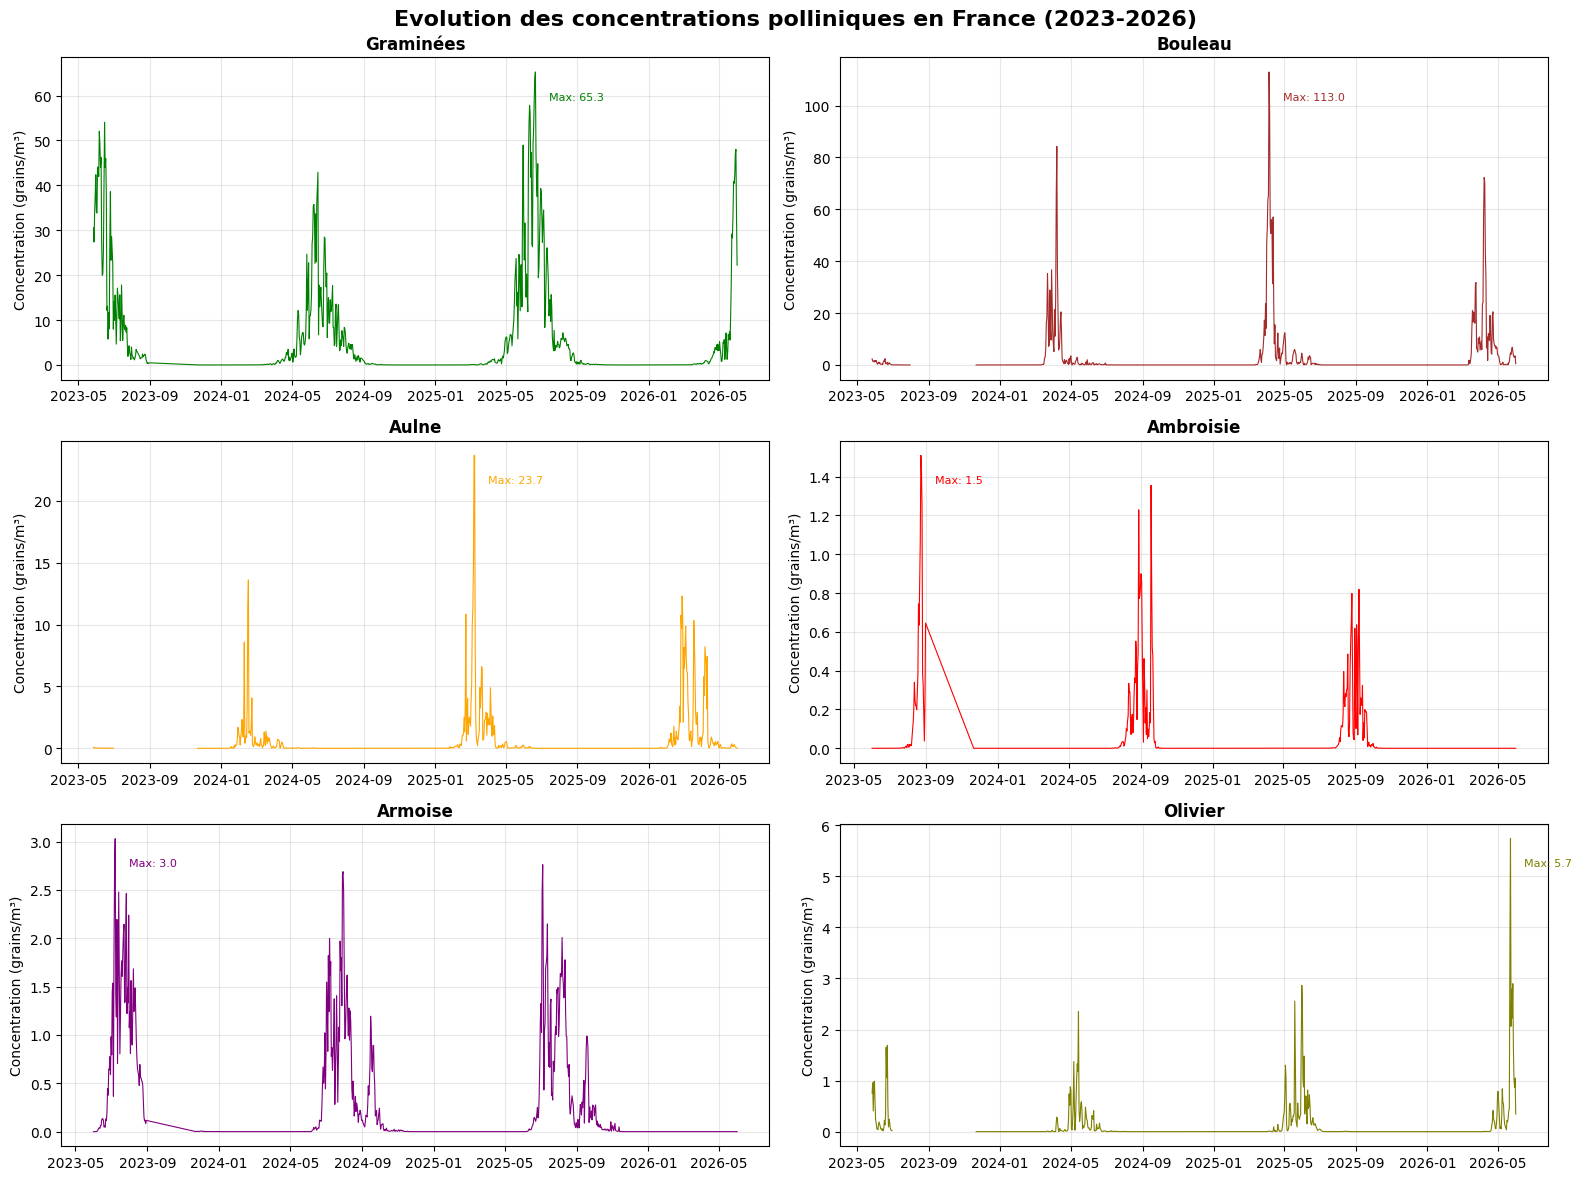

Graphique sauvegardé


In [4]:
# Graphique 1 — Evolution des concentrations polliniques par taxon
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('Evolution des concentrations polliniques en France (2023-2026)', 
             fontsize=16, fontweight='bold')

taxons = {
    'graminees':  ('Graminées', 'green', axes[0,0]),
    'bouleau':    ('Bouleau',   'brown', axes[0,1]),
    'aulne':      ('Aulne',     'orange', axes[1,0]),
    'ambroisie':  ('Ambroisie', 'red',   axes[1,1]),
    'armoise':    ('Armoise',   'purple', axes[2,0]),
    'olivier':    ('Olivier',   'olive', axes[2,1]),
}

for col, (label, color, ax) in taxons.items():
    ax.plot(pollen_daily['date'], pollen_daily[col], color=color, linewidth=0.8)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Concentration (grains/m³)')
    ax.grid(True, alpha=0.3)
    # Marquer les pics
    max_val = pollen_daily[col].max()
    max_date = pollen_daily.loc[pollen_daily[col].idxmax(), 'date']
    ax.annotate(f'Max: {max_val:.1f}', xy=(max_date, max_val),
                xytext=(10, -20), textcoords='offset points',
                fontsize=8, color=color)

plt.tight_layout()
plt.savefig('/Users/nellyta/Jedha/notebooks/pollen_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé")

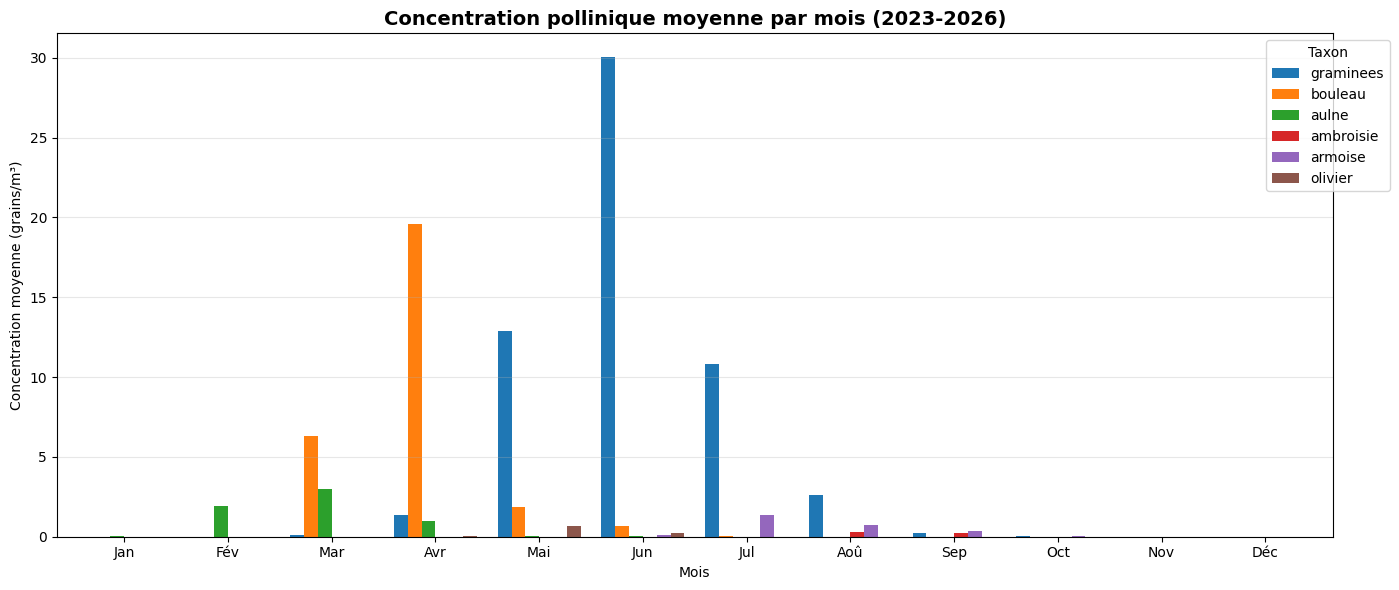

In [5]:
# Graphique 2 — Saisonnalité moyenne par mois
pollen_daily['mois'] = pollen_daily['date'].dt.month

saison = pollen_daily.groupby('mois')[
    ['graminees','bouleau','aulne','ambroisie','armoise','olivier']
].mean()

fig, ax = plt.subplots(figsize=(14, 6))
saison.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Concentration pollinique moyenne par mois (2023-2026)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Mois')
ax.set_ylabel('Concentration moyenne (grains/m³)')
ax.set_xticklabels(['Jan','Fév','Mar','Avr','Mai','Jun',
                    'Jul','Aoû','Sep','Oct','Nov','Déc'], rotation=0)
ax.legend(title='Taxon', bbox_to_anchor=(1.05, 1))
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('/Users/nellyta/Jedha/notebooks/pollen_saisonnalite.png', dpi=150, bbox_inches='tight')
plt.show()

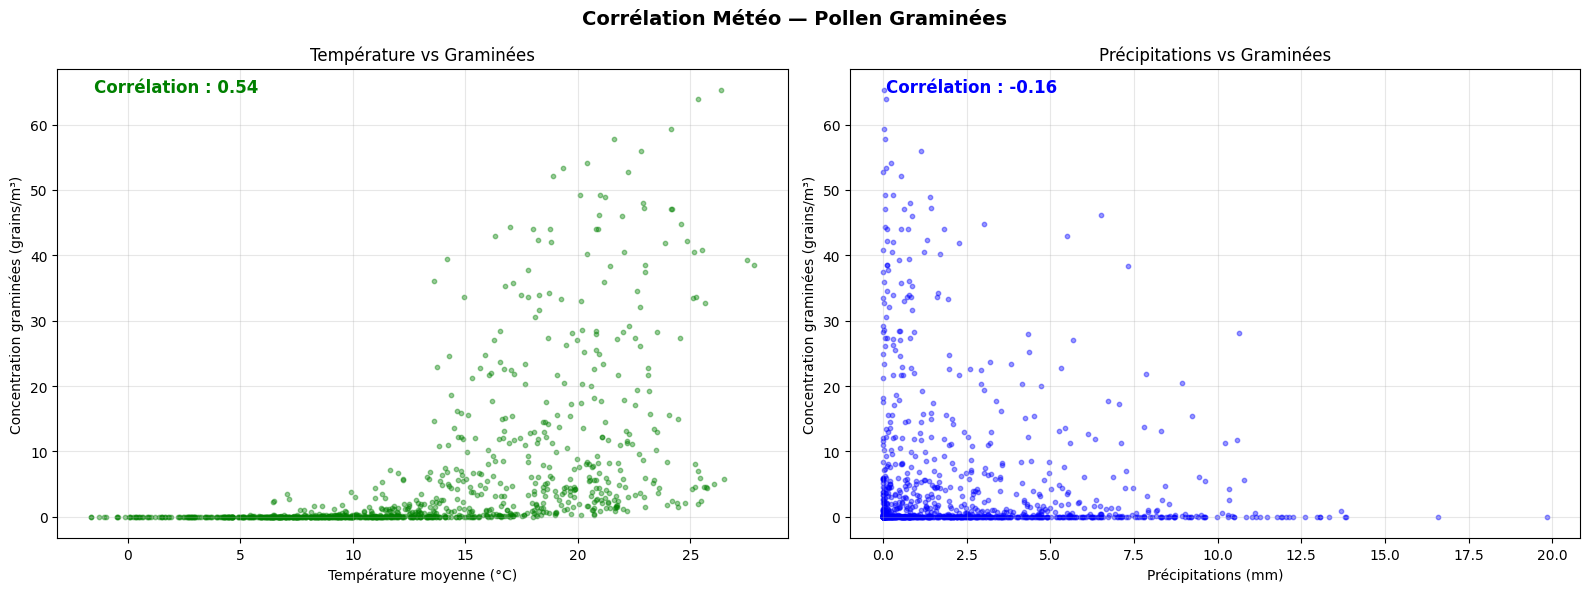

Corrélation température/graminées : 0.537
Corrélation précipitations/graminées : -0.156


In [6]:
# Graphique 3 — Corrélation température et graminées
meteo_daily = df_meteo.groupby('time').agg(
    temp_moy=('temperature_2m_mean', 'mean'),
    precip=('precipitation_sum', 'mean')
).reset_index().rename(columns={'time': 'date'})

merged = pollen_daily.merge(meteo_daily, on='date', how='inner')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Corrélation Météo — Pollen Graminées', fontsize=14, fontweight='bold')

# Température vs Graminées
axes[0].scatter(merged['temp_moy'], merged['graminees'], 
                alpha=0.4, color='green', s=10)
axes[0].set_xlabel('Température moyenne (°C)')
axes[0].set_ylabel('Concentration graminées (grains/m³)')
axes[0].set_title('Température vs Graminées')
axes[0].grid(True, alpha=0.3)

# Corrélation
corr_temp = merged['temp_moy'].corr(merged['graminees'])
axes[0].annotate(f'Corrélation : {corr_temp:.2f}', 
                 xy=(0.05, 0.95), xycoords='axes fraction',
                 fontsize=12, color='green', fontweight='bold')

# Précipitations vs Graminées
axes[1].scatter(merged['precip'], merged['graminees'], 
                alpha=0.4, color='blue', s=10)
axes[1].set_xlabel('Précipitations (mm)')
axes[1].set_ylabel('Concentration graminées (grains/m³)')
axes[1].set_title('Précipitations vs Graminées')
axes[1].grid(True, alpha=0.3)

corr_precip = merged['precip'].corr(merged['graminees'])
axes[1].annotate(f'Corrélation : {corr_precip:.2f}', 
                 xy=(0.05, 0.95), xycoords='axes fraction',
                 fontsize=12, color='blue', fontweight='bold')

plt.tight_layout()
plt.savefig('/Users/nellyta/Jedha/notebooks/correlation_meteo_pollen.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Corrélation température/graminées : {corr_temp:.3f}')
print(f'Corrélation précipitations/graminées : {corr_precip:.3f}')

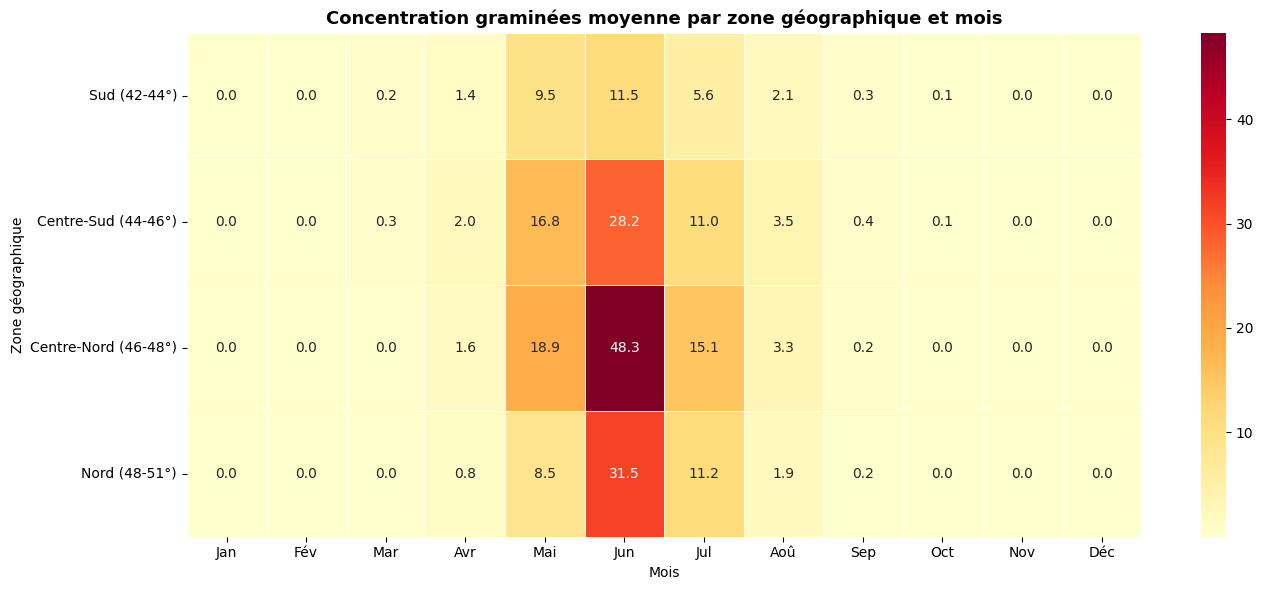

In [8]:
# Graphique 4 — Concentration graminées par région
pollen_region = df_pollen.copy()
pollen_region['date'] = pd.to_datetime(pollen_region['date'])
pollen_region['mois'] = pollen_region['date'].dt.month

# Agréger par région géographique (latitude)
pollen_region['zone'] = pd.cut(pollen_region['latitude'],
    bins=[42, 44, 46, 48, 51],
    labels=['Sud (42-44°)', 'Centre-Sud (44-46°)', 
            'Centre-Nord (46-48°)', 'Nord (48-51°)'])

heatmap_data = pollen_region.groupby(['zone','mois'])['graminees_conc'].mean().unstack()

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=ax, linewidths=0.5)
ax.set_title('Concentration graminées moyenne par zone géographique et mois', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mois')
ax.set_ylabel('Zone géographique')
ax.set_xticklabels(['Jan','Fév','Mar','Avr','Mai','Jun',
                    'Jul','Aoû','Sep','Oct','Nov','Déc'])
plt.tight_layout()
plt.savefig('/Users/nellyta/Jedha/notebooks/heatmap_pollen_region.png', dpi=150, bbox_inches='tight')
plt.show()

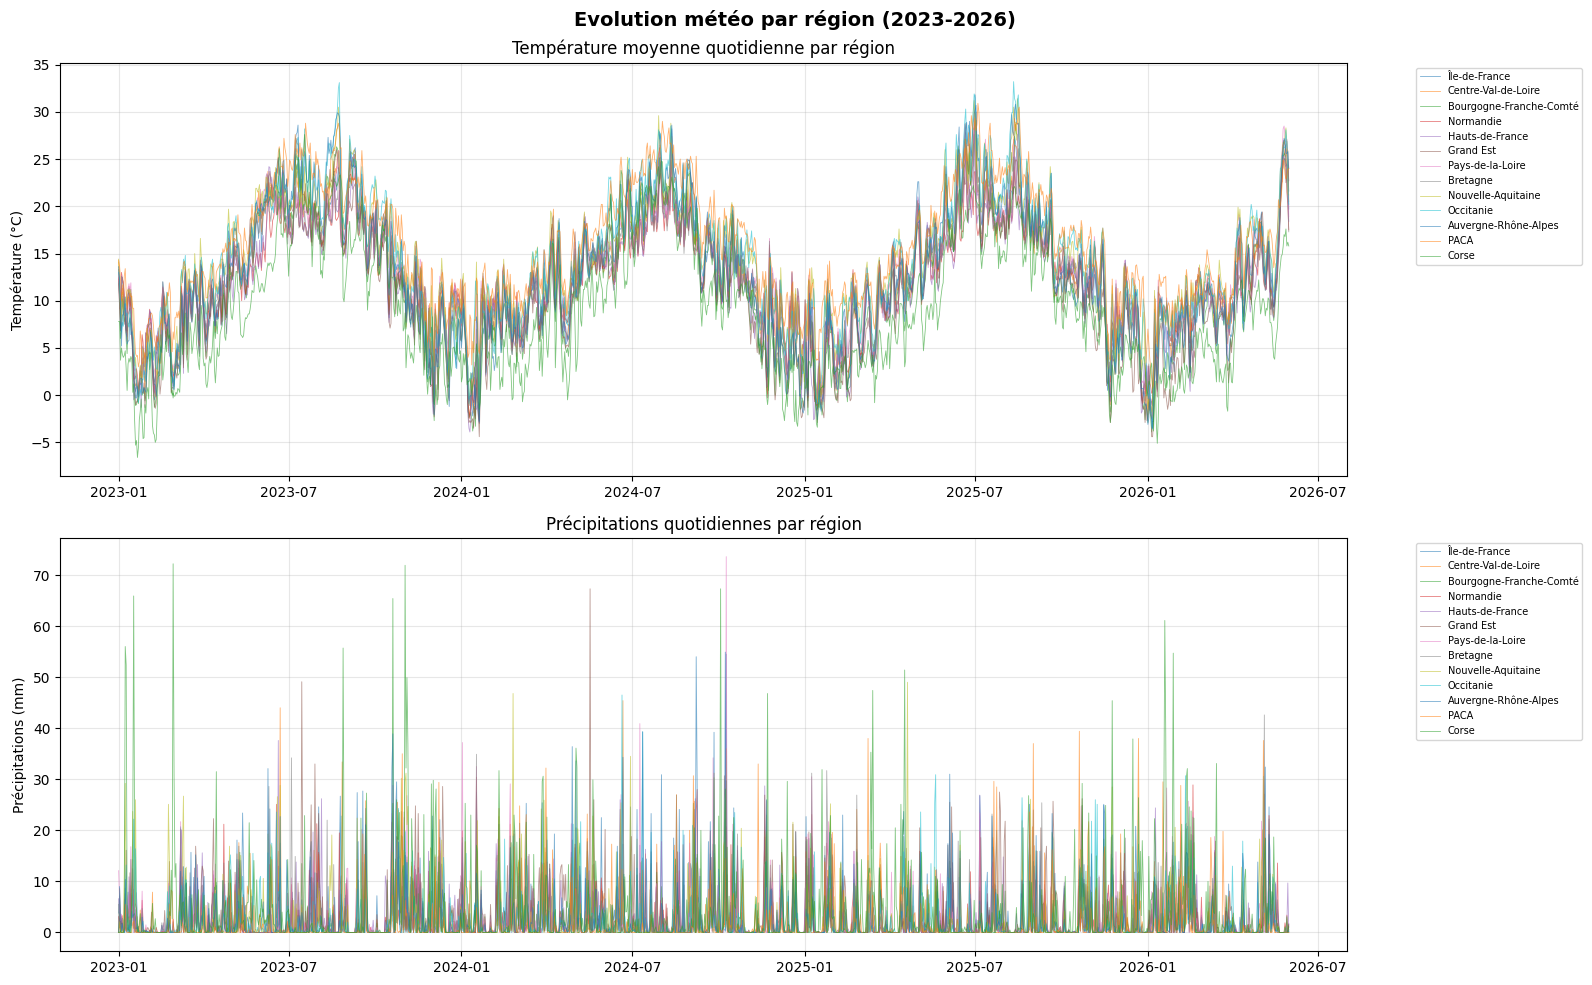

In [9]:
# Graphique 5 — Météo par région
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Evolution météo par région (2023-2026)', fontsize=14, fontweight='bold')

# Température
for region in df_meteo['region'].unique():
    subset = df_meteo[df_meteo['region'] == region]
    axes[0].plot(subset['time'], subset['temperature_2m_mean'], 
                 linewidth=0.6, alpha=0.6, label=region)
axes[0].set_title('Température moyenne quotidienne par région')
axes[0].set_ylabel('Température (°C)')
axes[0].grid(True, alpha=0.3)
axes[0].legend(bbox_to_anchor=(1.05, 1), fontsize=7)

# Précipitations
for region in df_meteo['region'].unique():
    subset = df_meteo[df_meteo['region'] == region]
    axes[1].plot(subset['time'], subset['precipitation_sum'], 
                 linewidth=0.6, alpha=0.6, label=region)
axes[1].set_title('Précipitations quotidiennes par région')
axes[1].set_ylabel('Précipitations (mm)')
axes[1].grid(True, alpha=0.3)
axes[1].legend(bbox_to_anchor=(1.05, 1), fontsize=7)

plt.tight_layout()
plt.savefig('/Users/nellyta/Jedha/notebooks/meteo_regions.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Synthèse EDA — Tableau des insights clés
print("=" * 60)
print("SYNTHÈSE EDA — POLLEN & MÉTÉO")
print("=" * 60)

print("\n DONNÉES")
print(f"  Période : {pollen_daily['date'].min().date()} → {pollen_daily['date'].max().date()}")
print(f"  Jours analysés : {len(pollen_daily)}")
print(f"  Régions météo  : {df_meteo['region'].nunique()}")

print("\n SAISONNALITÉ POLLEN")
for taxon in ['graminees','bouleau','aulne','ambroisie','armoise','olivier']:
    mois_pic = pollen_daily.groupby('mois')[taxon].mean().idxmax()
    val_max  = pollen_daily[taxon].max()
    mois_noms = {1:'Jan',2:'Fév',3:'Mar',4:'Avr',5:'Mai',6:'Jun',
                 7:'Jul',8:'Aoû',9:'Sep',10:'Oct',11:'Nov',12:'Déc'}
    print(f"  {taxon:<12} → pic en {mois_noms[mois_pic]}, max = {val_max:.1f} grains/m³")

print("\n CORRÉLATIONS AVEC LES GRAMINÉES")
print(f"  Température  : {merged['temp_moy'].corr(merged['graminees']):.3f}")
print(f"  Précipitations : {merged['precip'].corr(merged['graminees']):.3f}")

print("\n FEATURES ML RETENUES")
print("  graminees_conc     → variable cible pollen")
print("  rolling_mean_7j    → à créer en J2 (fenêtre glissante)")
print("  lag_7j, lag_14j    → à créer en J2 (décalage temporel)")
print("  temperature_2m_mean → feature météo principale")
print("  precipitation_sum   → feature météo secondaire")
print("  mois               → feature saisonnalité")
print("  saison_allergies   → flag avril-juillet")

print("\n" + "=" * 60)

SYNTHÈSE EDA — POLLEN & MÉTÉO

 DONNÉES
  Période : 2023-05-27 → 2026-06-01
  Jours analysés : 1021
  Régions météo  : 13

 SAISONNALITÉ POLLEN
  graminees    → pic en Jun, max = 65.3 grains/m³
  bouleau      → pic en Avr, max = 113.0 grains/m³
  aulne        → pic en Mar, max = 23.7 grains/m³
  ambroisie    → pic en Aoû, max = 1.5 grains/m³
  armoise      → pic en Jul, max = 3.0 grains/m³
  olivier      → pic en Mai, max = 5.7 grains/m³

 CORRÉLATIONS AVEC LES GRAMINÉES
  Température  : 0.537
  Précipitations : -0.156

 FEATURES ML RETENUES
  graminees_conc     → variable cible pollen
  rolling_mean_7j    → à créer en J2 (fenêtre glissante)
  lag_7j, lag_14j    → à créer en J2 (décalage temporel)
  temperature_2m_mean → feature météo principale
  precipitation_sum   → feature météo secondaire
  mois               → feature saisonnalité
  saison_allergies   → flag avril-juillet




Saisonnalité — Juin est le mois critique pour les graminées (30 grains/m³ en moyenne), Avril pour le bouleau (20 grains/m³). La fenêtre avril-juillet concentre 90% de l'exposition pollinique.
Géographie — Le Centre-Nord (Île-de-France, Grand Est) est la zone la plus exposée avec 48 grains/m³ en juin — ce sont aussi les régions avec le plus de consommation d'antihistaminiques dans Open Medic.
Météo — La température est corrélée à 0.54 avec les graminées — c'est une feature ML fiable. Les précipitations ont un effet légèrement négatif (-0.16) — la pluie "lave" le pollen.